# Chemical Data ML Project

This notebook trains two supervised models from `chem_excel_final.xlsx`.

- Absorbance regression from volume and concentration
- Colour prediction as RGB regression, converted back to HEX

The workbook contains a few incomplete rows and one obvious absorbance outlier (`52`). The notebook removes incomplete rows and filters that outlier before training.

In [2]:
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import HTML, display
from openpyxl import load_workbook
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.multioutput import MultiOutputRegressor

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

In [3]:
DATA_PATH = Path("chem_excel_final.xlsx")
if not DATA_PATH.exists():
    raise FileNotFoundError(f"Could not find {DATA_PATH.resolve()}")

raw = pd.read_excel(DATA_PATH, engine="openpyxl")
raw.columns = ["blank", "name", "conc", "wl_nm", "abs", "photos", "hex", "r", "g", "b", "hsl"]
raw.head()

,blank,name,conc,wl_nm,abs,photos,hex,r,g,b,hsl
0,NaN,5ml,0.2,640.0,0.08,Picture,NaN,NaN,NaN,NaN,NaN
1,NaN,5ml,0.4,640.0,0.14,Picture,NaN,NaN,NaN,NaN,NaN
2,NaN,5ml,0.6,640.0,0.21,NaN,#121A1E,18.0,26.0,30.0,"hsl(199, 25%, 9%)"
3,NaN,5ml,0.8,640.0,52.00,NaN,#081018,8.0,16.0,24.0,"hsl(210, 50%, 6%)"
4,NaN,5ml,1.0,640.0,0.33,NaN,#89BBB8,137.0,187.0,184.0,"hsl(176, 26%, 63%)"


In [4]:
df = raw.copy()
df["volume_label"] = df["name"].astype(str).str.strip()
df["volume_ml"] = df["volume_label"].str.extract(r"(\d+(?:\.\d+)?)").astype(float)
df["conc"] = pd.to_numeric(df["conc"], errors="coerce")
df["abs"] = pd.to_numeric(df["abs"], errors="coerce")
for col in ["r", "g", "b"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")
df["hex"] = df["hex"].astype(str).str.upper()
valid_hex = df["hex"].str.match(r"^#[0-9A-F]{6}$", na=False)

clean = df.loc[
    df["volume_ml"].notna()
    & df["conc"].notna()
    & df["abs"].notna()
    & valid_hex
    & df[["r", "g", "b"]].notna().all(axis=1)
].copy()

# Remove the obvious absorbance typo/outlier so the regression is not dominated by one bad row.
clean = clean.loc[clean["abs"] <= 10].copy()
clean.reset_index(drop=True, inplace=True)
clean[["volume_label", "volume_ml", "conc", "abs", "hex", "r", "g", "b"]].head(10)

,volume_label,volume_ml,conc,abs,hex,r,g,b
0,5ml,5.0,0.6,0.21,#121A1E,18.0,26.0,30.0
1,5ml,5.0,1.0,0.33,#89BBB8,137.0,187.0,184.0
2,5ml,5.0,1.2,0.40,#73B4BA,115.0,180.0,186.0
3,5ml,5.0,1.4,0.48,#72B9BA,114.0,185.0,186.0
4,5ml,5.0,1.6,0.53,#5EB8C2,94.0,184.0,194.0
5,5ml,5.0,1.8,0.56,#5ABAC3,90.0,186.0,195.0
6,5ml,5.0,2.0,0.63,#54B4BC,84.0,180.0,188.0
7,5ml,5.0,2.2,0.69,#3BB5C7,59.0,181.0,199.0
8,5ml,5.0,2.4,0.74,#36B4C4,54.0,180.0,196.0
9,5ml,5.0,2.6,0.82,#29A9BB,41.0,169.0,187.0


In [5]:
print(f"Raw rows: {len(raw)}")
print(f"Usable rows after cleaning: {len(clean)}")
print("Volumes present:", sorted(clean["volume_label"].unique()))
print("Absorbance range:", float(clean["abs"].min()), "to", float(clean["abs"].max()))
print()
display(clean.groupby("volume_label")["conc"].agg(["count", "min", "max"]))

Raw rows: 101
Usable rows after cleaning: 90
Volumes present: ['1ml', '2ml', '3ml', '4ml', '5ml']
Absorbance range: 0.09 to 2.0



,count,min,max
volume_label,,,
1ml,10,1.00,10.00
2ml,12,0.50,6.00
3ml,20,0.30,6.00
4ml,19,0.25,4.75
5ml,29,0.60,6.40


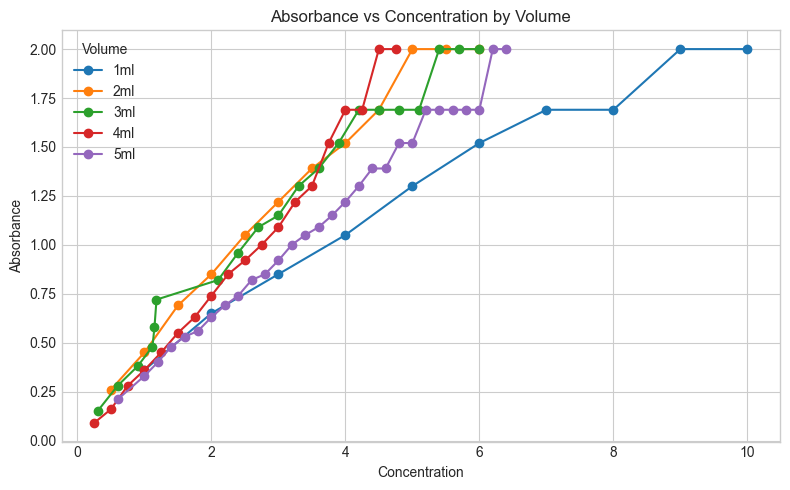

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))
for label, group in clean.groupby("volume_label"):
    ax.plot(group["conc"], group["abs"], marker="o", linewidth=1.5, label=label)
ax.set_title("Absorbance vs Concentration by Volume")
ax.set_xlabel("Concentration")
ax.set_ylabel("Absorbance")
ax.legend(title="Volume")
plt.tight_layout()
plt.show()

In [7]:
feature_cols = ["volume_ml", "conc"]
X = clean[feature_cols]
y_abs = clean["abs"]
y_rgb = clean[["r", "g", "b"]]

X_train, X_test, y_abs_train, y_abs_test, y_rgb_train, y_rgb_test = train_test_split(
    X, y_abs, y_rgb, test_size=0.2, random_state=42
)

print("Train rows:", len(X_train))
print("Test rows:", len(X_test))
X_train.head()

Train rows: 72
Test rows: 18


,volume_ml,conc
49,3.0,0.6
62,3.0,4.5
73,2.0,3.0
69,2.0,1.0
76,2.0,4.5


In [8]:
abs_model = RandomForestRegressor(
    n_estimators=400,
    random_state=42,
    min_samples_leaf=2,
)
abs_model.fit(X_train, y_abs_train)
abs_pred = abs_model.predict(X_test)

abs_mae = mean_absolute_error(y_abs_test, abs_pred)
abs_rmse = np.sqrt(mean_squared_error(y_abs_test, abs_pred))
abs_r2 = r2_score(y_abs_test, abs_pred)

print("Absorbance model")
print("MAE :", round(abs_mae, 4))
print("RMSE:", round(abs_rmse, 4))
print("R2  :", round(abs_r2, 4))

Absorbance model
MAE : 0.1106
RMSE: 0.1286
R2  : 0.9385


In [9]:
color_feature_cols = ["volume_ml", "conc", "abs_pred"]
train_abs_pred = abs_model.predict(X_train)
test_abs_pred = abs_model.predict(X_test)

X_rgb_train = X_train.copy().assign(abs_pred=train_abs_pred)
X_rgb_test = X_test.copy().assign(abs_pred=test_abs_pred)

rgb_model = MultiOutputRegressor(
    RandomForestRegressor(
        n_estimators=500,
        random_state=42,
        min_samples_leaf=2,
    )
)
rgb_model.fit(X_rgb_train, y_rgb_train)
rgb_pred = rgb_model.predict(X_rgb_test)

rgb_mae = mean_absolute_error(y_rgb_test, rgb_pred)
rgb_mae_channels = mean_absolute_error(y_rgb_test, rgb_pred, multioutput="raw_values")
rgb_rmse = np.sqrt(mean_squared_error(y_rgb_test, rgb_pred))
rgb_r2 = r2_score(y_rgb_test, rgb_pred)
rgb_r2_channels = r2_score(y_rgb_test, rgb_pred, multioutput="raw_values")

print("Colour model")
print("MAE overall:", round(rgb_mae, 4))
print("MAE R/G/B :", [round(float(x), 4) for x in rgb_mae_channels])
print("RMSE overall:", round(rgb_rmse, 4))
print("R2 overall:", round(rgb_r2, 4))
print("R2 R/G/B   :", [round(float(x), 4) for x in rgb_r2_channels])

Colour model
MAE overall: 17.0314
MAE R/G/B : [21.0414, 14.9588, 15.094]
RMSE overall: 32.6486
R2 overall: 0.2818
R2 R/G/B   : [-0.0176, 0.292, 0.5711]


In [10]:
def rgb_to_hex(rgb_values):
    r, g, b = (int(np.clip(round(value), 0, 255)) for value in rgb_values)
    return f"#{r:02X}{g:02X}{b:02X}"


def predict_sample(volume_ml, concentration):
    sample = pd.DataFrame({"volume_ml": [volume_ml], "conc": [concentration]})
    predicted_abs = float(abs_model.predict(sample)[0])
    sample_color = sample.assign(abs_pred=[predicted_abs])
    predicted_rgb = np.rint(np.clip(rgb_model.predict(sample_color)[0], 0, 255)).astype(int)
    predicted_hex = rgb_to_hex(predicted_rgb)
    return {
        "volume_ml": float(volume_ml),
        "concentration": float(concentration),
        "predicted_absorbance": predicted_abs,
        "predicted_rgb": tuple(int(v) for v in predicted_rgb),
        "predicted_hex": predicted_hex,
    }

example = predict_sample(3, 1.5)
example

{'volume_ml': 3.0,
 'concentration': 1.5,
 'predicted_absorbance': 0.5574097619047623,
 'predicted_rgb': (99, 163, 192),
 'predicted_hex': '#63A3C0'}

In [11]:
ARTIFACT_DIR = Path("artifacts")
ARTIFACT_DIR.mkdir(exist_ok=True)

joblib.dump(abs_model, ARTIFACT_DIR / "absorbance_model.joblib")
joblib.dump(rgb_model, ARTIFACT_DIR / "colour_model_rgb.joblib")
joblib.dump({
    "abs_feature_cols": feature_cols,
    "color_feature_cols": color_feature_cols,
    "clean_rows": len(clean),
    "volume_labels": sorted(clean["volume_label"].unique().tolist()),
}, ARTIFACT_DIR / "model_metadata.joblib")

print("Saved models to:", ARTIFACT_DIR.resolve())

Saved models to: C:\Users\Jyothi\Chemistry\artifacts


In [12]:
ARTIFACT_DIR = Path("artifacts")
ARTIFACT_DIR.mkdir(exist_ok=True)

joblib.dump(abs_model, ARTIFACT_DIR / "absorbance_model.joblib")
joblib.dump(rgb_model, ARTIFACT_DIR / "colour_model_rgb.joblib")
joblib.dump({
    "feature_cols": feature_cols,
    "clean_rows": len(clean),
    "volume_labels": sorted(clean["volume_label"].unique().tolist()),
}, ARTIFACT_DIR / "model_metadata.joblib")

print("Saved models to:", ARTIFACT_DIR.resolve())

Saved models to: C:\Users\Jyothi\Chemistry\artifacts


## Interactive Predictor

Use the fields below to enter volume (mL) and concentration, then click **Predict** to get absorbance and colour from the trained models.

In [ ]:
import ipywidgets as widgets
from IPython.display import HTML, clear_output, display

volume_input = widgets.FloatText(
    value=3.0,
    description="Volume (mL):",
    step=0.1,
    style={"description_width": "initial"},
    layout=widgets.Layout(width="260px"),
)

conc_input = widgets.FloatText(
    value=1.5,
    description="Concentration:",
    step=0.1,
    style={"description_width": "initial"},
    layout=widgets.Layout(width="260px"),
)

predict_button = widgets.Button(
    description="Predict",
    button_style="primary",
    icon="check",
)

prediction_output = widgets.Output()


def on_predict_click(_):
    with prediction_output:
        clear_output(wait=True)
        try:
            result = predict_sample(volume_input.value, conc_input.value)
        except NameError:
            print("Run the model-training cells first (the cell that defines predict_sample).")
            return

        swatch = result["predicted_hex"]
        display(
            HTML(
                f"<div style='margin-top:8px;width:240px;height:70px;border:1px solid #333;"
                f"background:{swatch};display:flex;align-items:center;justify-content:center;"
                f"color:white;font-weight:700;font-family:sans-serif;'>{swatch}</div>"
            )
        )
        print(f"Predicted absorbance: {result['predicted_absorbance']:.4f}")
        print(f"Predicted RGB: {result['predicted_rgb']}")
        print(f"Predicted HEX: {result['predicted_hex']}")


predict_button.on_click(on_predict_click)

ui = widgets.VBox([
    widgets.HBox([volume_input, conc_input]),
    predict_button,
    prediction_output,
])

display(ui)
on_predict_click(None)

print("If you only see text like 'VBox(...)', enable notebook widget rendering in VS Code and rerun this cell.")

If you only see text like 'VBox(...)', enable notebook widget rendering in VS Code and rerun this cell.


## Notes

- The workbook is small, so the model is intentionally simple and easy to inspect.
- Absorbance is predicted first, then the color model uses that predicted absorbance as an intermediate feature. That makes the color step closer to the actual chemistry in the sheet.
- Colour is still returned as RGB and HEX because that is a better fit for supervised regression than treating each HEX string as a separate class.
- If you want, the next step is to turn this notebook into an interactive predictor with input widgets.